# Spotify Songs: Data for the Exploratory Data Analysis Project
## Tidy Tuesday: Spotify Songs



## Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Read Data

In [2]:
songs_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv'

df = pd.read_csv( songs_url )

## A. Introduction
Project Summary – Predicting Song Popularity

This project was framed as a classification problem aimed at predicting a song's popularity level. Rather than treating popularity as a continuous score, I categorized the songs into three classes:

Very popular (popularity > 80)

Popular (50 < popularity ≤ 80)

Not popular (popularity ≤ 50)

To fit, predict, and tune classification models effectively, I converted this into a binary classification problem, combining the “very popular” and “popular” songs into one group (popular) and treating the rest as not popular.

#### Major Findings
From the initial exploratory data analysis (EDA), I identified a significant issue of class imbalance—a large portion of songs had a popularity score of zero. This imbalance influenced the model training and testing phases, leading to lower accuracy and ROC AUC scores across multiple models.

Despite implementing regularization techniques like Lasso, Ridge, and Elastic Net logistic regression, model performance remained limited. Even after hyperparameter tuning using cross-validation, these models struggled to generalize effectively due to the overwhelming number of low-popularity samples.

#### Influential Inputs/Features
The continuous features—danceability, energy, and log-transformed tempo—did not show strong predictive power on their own. However, once I introduced the categorical feature playlist_genre, performance improved noticeably. This suggests that genre has a more direct relationship with popularity, possibly because certain genres tend to dominate streaming platforms or trends.

#### Supporting Evidence
My conclusions were supported both through predictive modeling and EDA. The predictive results validated the trends observed during exploration. For instance, EDA revealed that certain genres clustered around higher popularity scores, a pattern that models like logistic regression were able to detect when categorical variables were included.

#### EDA Insights
EDA was instrumental in identifying key patterns—particularly the imbalance in popularity distribution and the preliminary relationships between features. It helped establish expectations and hypotheses that were later validated (or challenged) through modeling. Without EDA, I wouldn't have known how skewed the response variable was, nor the limited distribution of some features.

#### Clustering and Model Consistency
Yes, clustering results were consistent with what the predictive models revealed. When I clustered songs based on audio features, the groups that emerged aligned with the genre-based performance patterns and popularity levels. This reinforced the idea that genre plays a pivotal role in driving popularity.

#### Skills Learned
- Through this project, I developed and applied several skills, including:

- Data preprocessing, including standardization and transformation (e.g., applying log to skewed variables)

- Handling imbalanced datasets

- Feature engineering and encoding categorical variables

- Building and tuning classification models, including regularized logistic regression

- Cross-validation techniques to properly evaluate models

- Data visualization and communication, especially using heatmaps, performance plots, and summary tables

- Model interpretation and comparison, including accuracy, sensitivity, specificity, and ROC AUC

This end-to-end project allowed me to experience the full lifecycle of a machine learning pipeline, from raw data to actionable insights.

While this project focused specifically on predicting song popularity, it provided me with foundational data science and analytical skills that are highly transferable to many other applications, including those in my specific area of interest.

Some of the key general skills I can take away include:

- Problem Framing: I learned how to translate a vague or broad question (“What makes a song popular?”) into a structured, solvable machine learning task. This ability to define a problem scope clearly is crucial in any domain.

- Data Cleaning and Preprocessing: The project emphasized the importance of properly handling missing data, transforming skewed features, and applying preprocessing (e.g., standardization) within cross-validation folds. These are critical steps in ensuring models are robust and generalizable, regardless of the dataset or industry.

- Dealing with Class Imbalance: I gained hands-on experience managing imbalanced classification problems, a common challenge in areas like fraud detection, healthcare, and user behavior modeling.

- Model Selection and Regularization: Through logistic regression variants (Ridge, Lasso, Elastic Net), I learned how to balance model complexity and interpretability, and how to prevent overfitting using regularization techniques. This is essential when applying models in real-world scenarios where generalization matters more than perfect accuracy on training data.

- Cross-Validation & Evaluation Metrics: I understood how to choose appropriate performance metrics based on the output type and how to use cross-validation to get an honest estimate of model performance. This is especially valuable in domains where data is expensive or limited.

- Communication of Results: Creating visualizations and structured interpretations trained me to communicate findings effectively—not just technically, but also with clarity and purpose, which is crucial for collaboration and decision-making in any field.

## B. Exploratory Data Analysis

Now we will create a new variable call `df01` and save the data that we will be using.


In [3]:
df01 = df[['track_id', 'track_popularity','playlist_genre', 'danceability','track_album_release_date', 'tempo', 'energy']].copy()

In [4]:
df01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_popularity          32833 non-null  int64  
 2   playlist_genre            32833 non-null  object 
 3   danceability              32833 non-null  float64
 4   track_album_release_date  32833 non-null  object 
 5   tempo                     32833 non-null  float64
 6   energy                    32833 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 1.8+ MB


 Number of rows and columns

In [5]:
df01.shape

(32833, 7)

Column names and their associated data types

In [6]:
df01.dtypes

track_id                     object
track_popularity              int64
playlist_genre               object
danceability                float64
track_album_release_date     object
tempo                       float64
energy                      float64
dtype: object

 Number of missing values for each column

In [7]:
df01.isna().sum()

track_id                    0
track_popularity            0
playlist_genre              0
danceability                0
track_album_release_date    0
tempo                       0
energy                      0
dtype: int64

 Number of unique values for each column

In [8]:
df01.nunique()

track_id                    28356
track_popularity              101
playlist_genre                  6
danceability                  822
track_album_release_date     4530
tempo                       17684
energy                        952
dtype: int64

Here we can see that `track_id` unique values does not match with the total of rows of out data. This can mean that there is duplicated data. Let's confirm this with the following code.

In [9]:
df01.duplicated(subset='track_id').sum()

4477

Here we can see that there are 4,477 of duplicated data. Now that we know there is duplicated data we must remove this duplicated data.


In [10]:
df01 = df01.drop_duplicates(subset='track_id', keep='first')

In [11]:
df01.track_id.value_counts().sum()

28356

Let's explore again the data to confirm we remove the duplicated data.


In [12]:
df01.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  28356 non-null  object 
 1   track_popularity          28356 non-null  int64  
 2   playlist_genre            28356 non-null  object 
 3   danceability              28356 non-null  float64
 4   track_album_release_date  28356 non-null  object 
 5   tempo                     28356 non-null  float64
 6   energy                    28356 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 1.7+ MB


## Number of rows and columns

In [13]:
df01.shape

(28356, 7)

## Column names and their associated data types

In [14]:
df01.dtypes

track_id                     object
track_popularity              int64
playlist_genre               object
danceability                float64
track_album_release_date     object
tempo                       float64
energy                      float64
dtype: object

## Number of missing values for each column

In [15]:
df01.isna().sum()

track_id                    0
track_popularity            0
playlist_genre              0
danceability                0
track_album_release_date    0
tempo                       0
energy                      0
dtype: int64

## Number of unique values for each column

In [16]:
df01.nunique()

track_id                    28356
track_popularity              101
playlist_genre                  6
danceability                  822
track_album_release_date     4530
tempo                       17684
energy                        952
dtype: int64

Since this is a `Classification` problem we must change numeric column `track_popularity`to non-numeric column.

In [17]:
conditions = [
    df01["track_popularity"] > 80,  # Very Popular
    (df01["track_popularity"] > 50) & (df01["track_popularity"] <= 80),  # Popular
    df01["track_popularity"] <= 50  # Not Popular
]

choices = ["very_popular", "popular", "not_popular"]

df01["popularity_category"] = np.select(conditions, choices, default="unknown")

Let's extract the year from the `track_album_release_date ` and assign it to a new column `release_year`.

In [18]:
df01['release_year'] = df01['track_album_release_date'].str.extract(r'(\d{4})').astype(int)

Now lets turn release year to a categorical variable for better visialize the data.

In [19]:
df01['bin_year'] = np.where( df01.release_year < 2010, 'older', 'recent')

In [20]:
df01.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  28356 non-null  object 
 1   track_popularity          28356 non-null  int64  
 2   playlist_genre            28356 non-null  object 
 3   danceability              28356 non-null  float64
 4   track_album_release_date  28356 non-null  object 
 5   tempo                     28356 non-null  float64
 6   energy                    28356 non-null  float64
 7   popularity_category       28356 non-null  object 
 8   release_year              28356 non-null  int32  
 9   bin_year                  28356 non-null  object 
dtypes: float64(3), int32(1), int64(1), object(5)
memory usage: 2.3+ MB


## From WIDE to LONG Format

In [21]:
df_features = df01[['danceability', 'tempo', 'energy']].copy()

In [22]:
df_features

,danceability,tempo,energy
0,0.748,122.036,0.916
1,0.726,99.972,0.815
2,0.675,124.008,0.931
3,0.718,121.956,0.930
4,0.650,123.976,0.833
...,...,...,...
32828,0.428,128.170,0.922
32829,0.522,128.041,0.786
32830,0.529,127.989,0.821
32831,0.626,128.008,0.888


In [23]:
df_features.melt(ignore_index=False)

,variable,value
0,danceability,0.748
1,danceability,0.726
2,danceability,0.675
3,danceability,0.718
4,danceability,0.650
...,...,...
32828,energy,0.922
32829,energy,0.786
32830,energy,0.821
32831,energy,0.888


In [24]:
df_features.reset_index().\
rename(columns={'index': 'rowid'}).\
melt(id_vars=['rowid'])

,rowid,variable,value
0,0,danceability,0.748
1,1,danceability,0.726
2,2,danceability,0.675
3,3,danceability,0.718
4,4,danceability,0.650
...,...,...,...
85063,32828,energy,0.922
85064,32829,energy,0.786
85065,32830,energy,0.821
85066,32831,energy,0.888


In [25]:
df_objects = df01[['track_id', 'popularity_category','playlist_genre', 'bin_year']]

In [26]:
id_cols = ['rowid'] + df_objects.columns.to_list()

In [27]:
id_cols

['rowid', 'track_id', 'popularity_category', 'playlist_genre', 'bin_year']

In [28]:
df01.reset_index().\
rename(columns={'index': 'rowid'}).\
melt(id_vars=id_cols)

,rowid,track_id,popularity_category,playlist_genre,bin_year,variable,value
0,0,6f807x0ima9a1j3VPbc7VN,popular,pop,recent,track_popularity,66
1,1,0r7CVbZTWZgbTCYdfa2P31,popular,pop,recent,track_popularity,67
2,2,1z1Hg7Vb0AhHDiEmnDE79l,popular,pop,recent,track_popularity,70
3,3,75FpbthrwQmzHlBJLuGdC7,popular,pop,recent,track_popularity,60
4,4,1e8PAfcKUYoKkxPhrHqw4x,popular,pop,recent,track_popularity,69
...,...,...,...,...,...,...,...
170131,32828,7bxnKAamR3snQ1VGLuVfC1,not_popular,edm,recent,release_year,2014
170132,32829,5Aevni09Em4575077nkWHz,not_popular,edm,recent,release_year,2013
170133,32830,7ImMqPP3Q1yfUHvsdn7wEo,not_popular,edm,recent,release_year,2014
170134,32831,2m69mhnfQ1Oq6lGtXuYhgX,not_popular,edm,recent,release_year,2014


In [29]:
df_lf = df01.reset_index().\
rename(columns={'index': 'rowid'}).\
melt(id_vars=id_cols, value_vars=df_features.columns) 

In [30]:
df_lf

,rowid,track_id,popularity_category,playlist_genre,bin_year,variable,value
0,0,6f807x0ima9a1j3VPbc7VN,popular,pop,recent,danceability,0.748
1,1,0r7CVbZTWZgbTCYdfa2P31,popular,pop,recent,danceability,0.726
2,2,1z1Hg7Vb0AhHDiEmnDE79l,popular,pop,recent,danceability,0.675
3,3,75FpbthrwQmzHlBJLuGdC7,popular,pop,recent,danceability,0.718
4,4,1e8PAfcKUYoKkxPhrHqw4x,popular,pop,recent,danceability,0.650
...,...,...,...,...,...,...,...
85063,32828,7bxnKAamR3snQ1VGLuVfC1,not_popular,edm,recent,energy,0.922
85064,32829,5Aevni09Em4575077nkWHz,not_popular,edm,recent,energy,0.786
85065,32830,7ImMqPP3Q1yfUHvsdn7wEo,not_popular,edm,recent,energy,0.821
85066,32831,2m69mhnfQ1Oq6lGtXuYhgX,not_popular,edm,recent,energy,0.888


## Counts of categorical variables


C:\Users\User\AppData\Local\Temp\ipykernel_7392\3611966847.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data = df01, x='popularity_category', kind='count',palette='pastel')
C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


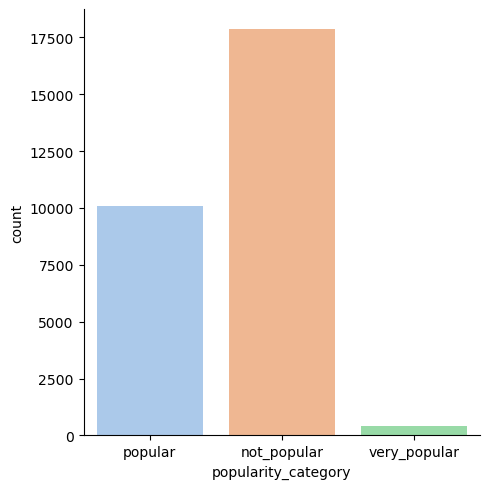

In [31]:
sns.catplot(data = df01, x='popularity_category', kind='count',palette='pastel')

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7392\3360915838.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data = df01, y='release_year', kind='count', height=11, aspect=1.5, palette='pastel')
C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


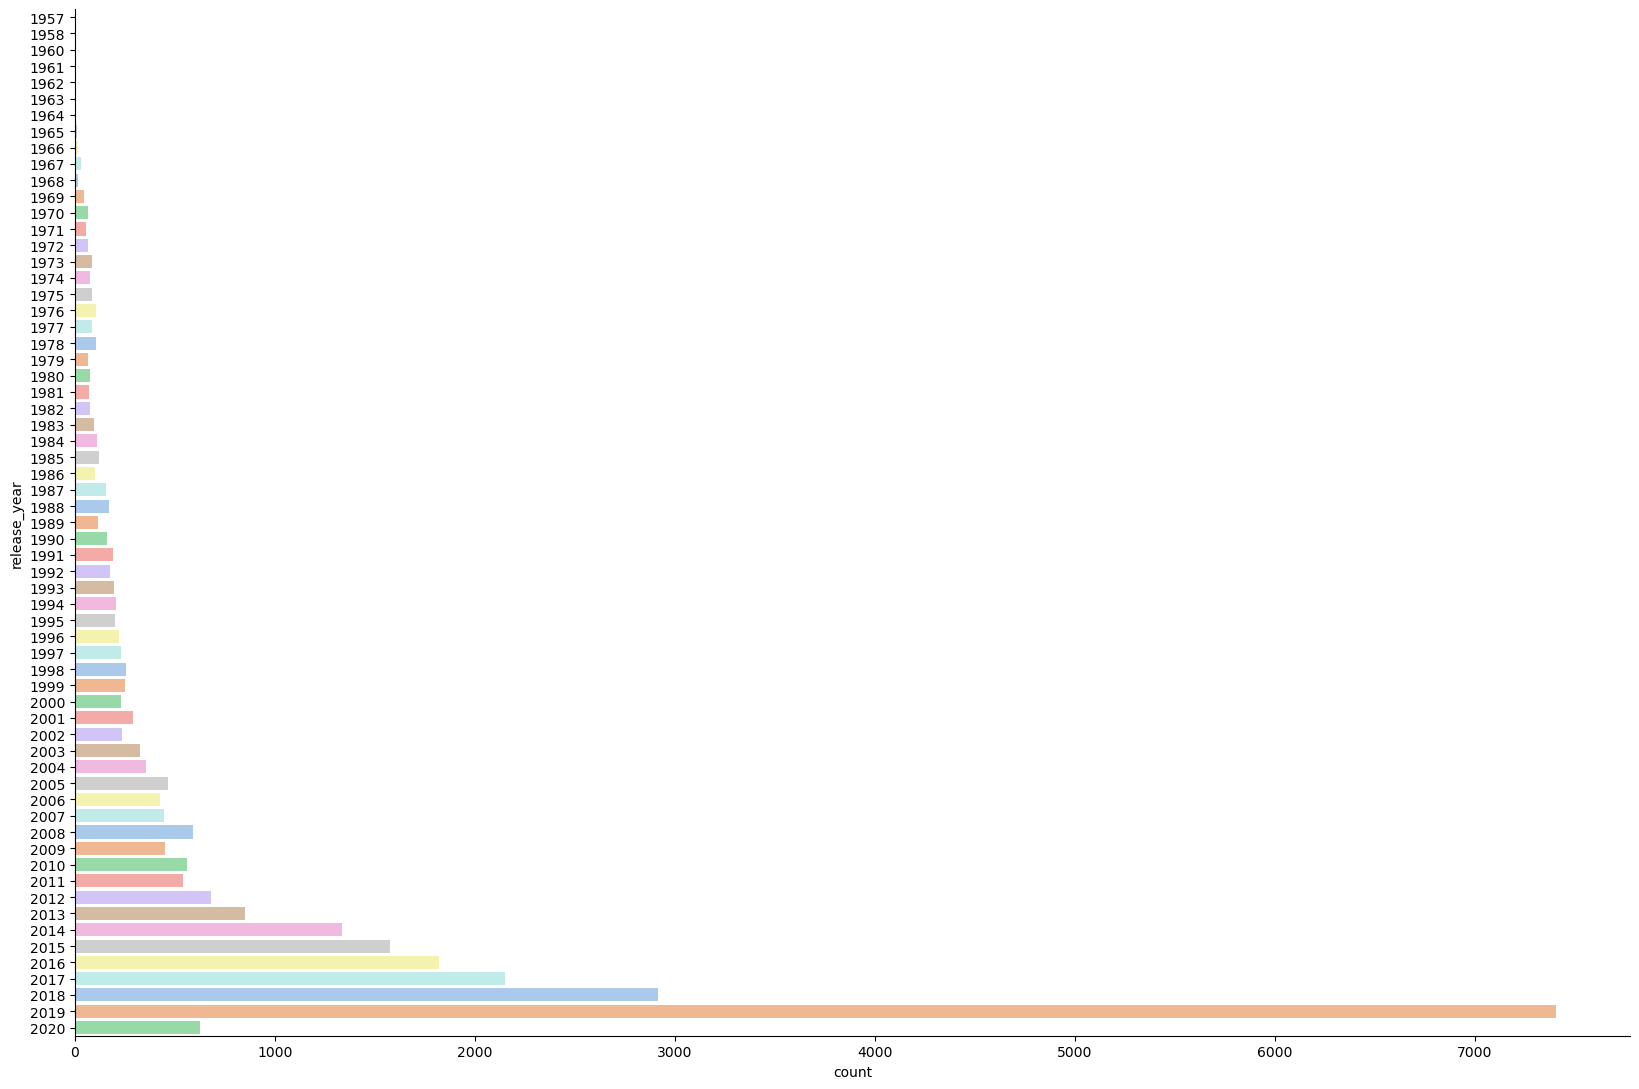

In [32]:
sns.catplot(data = df01, y='release_year', kind='count', height=11, aspect=1.5, palette='pastel')

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7392\1971322265.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data = df01, x='bin_year', kind='count', height=7, palette='coolwarm')
C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


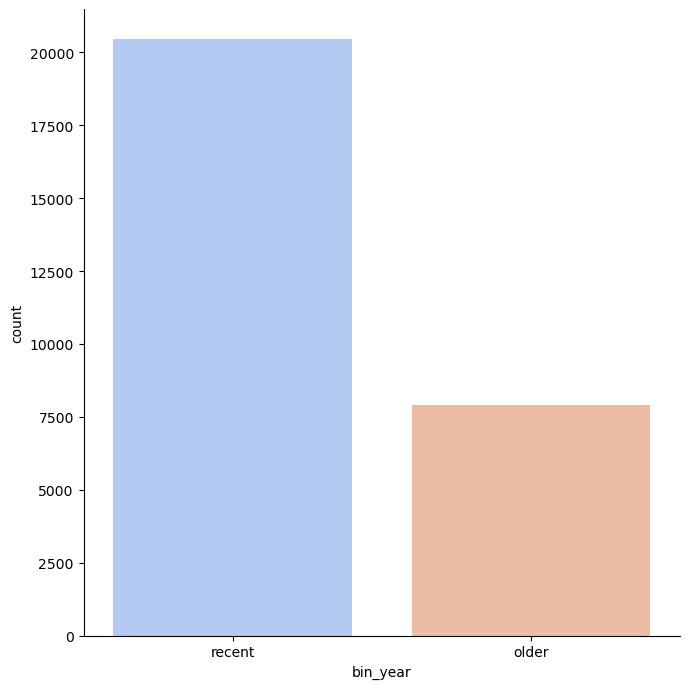

In [33]:
sns.catplot(data = df01, x='bin_year', kind='count', height=7, palette='coolwarm')

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7392\1827126910.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data = df01, x='playlist_genre', kind='count',palette='pastel')
C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


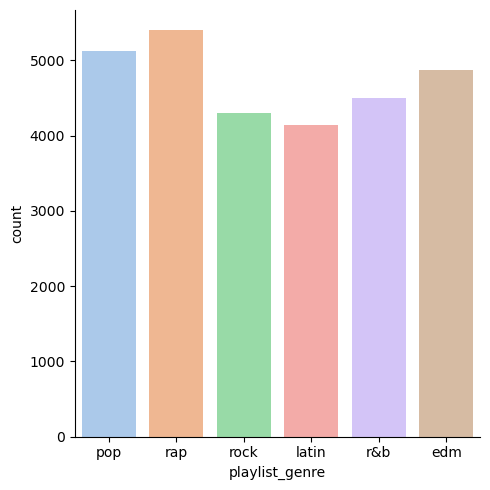

In [34]:
sns.catplot(data = df01, x='playlist_genre', kind='count',palette='pastel')

plt.show()

## Distribitions of continuous variables

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


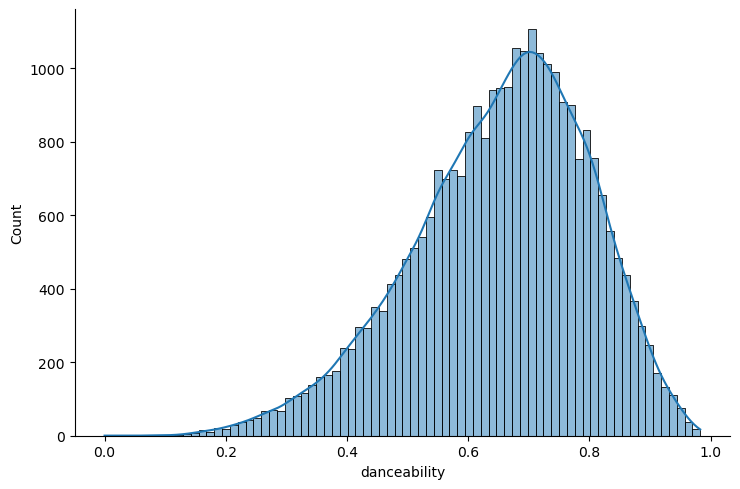

In [35]:
sns.displot(data = df01, x='danceability', kind='hist', kde=True, aspect=1.5)

plt.show()

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


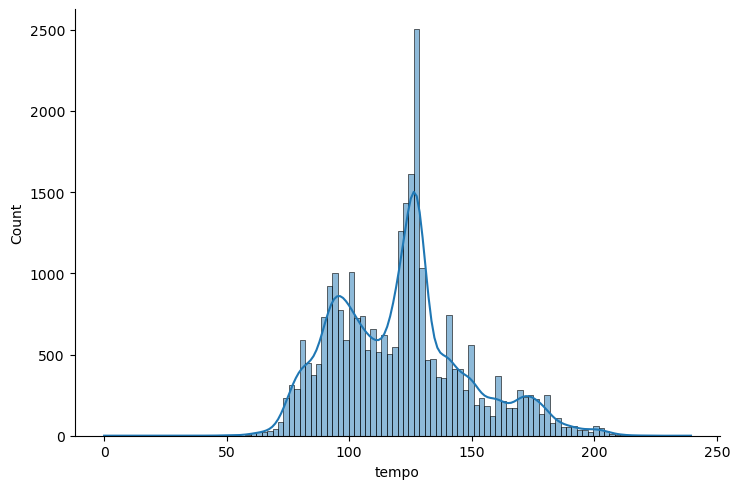

In [36]:
sns.displot(data = df01, x='tempo', kind='hist', kde=True, aspect=1.5)

plt.show()

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


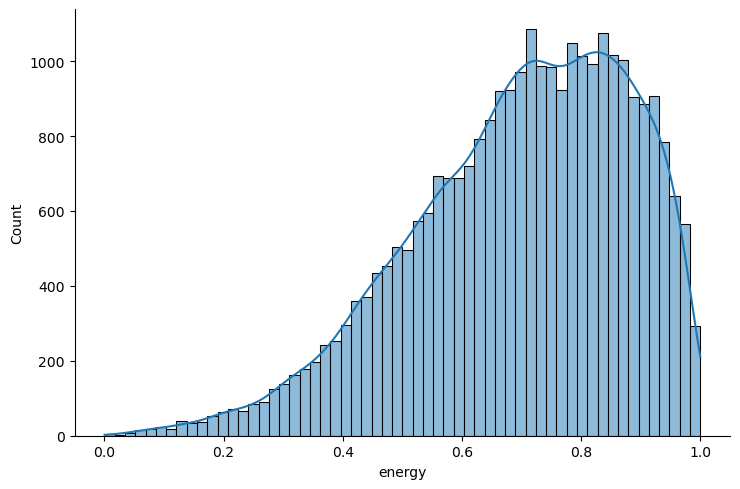

In [37]:
sns.displot(data = df01, x='energy', kind='hist', kde=True, aspect=1.5)

plt.show()

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


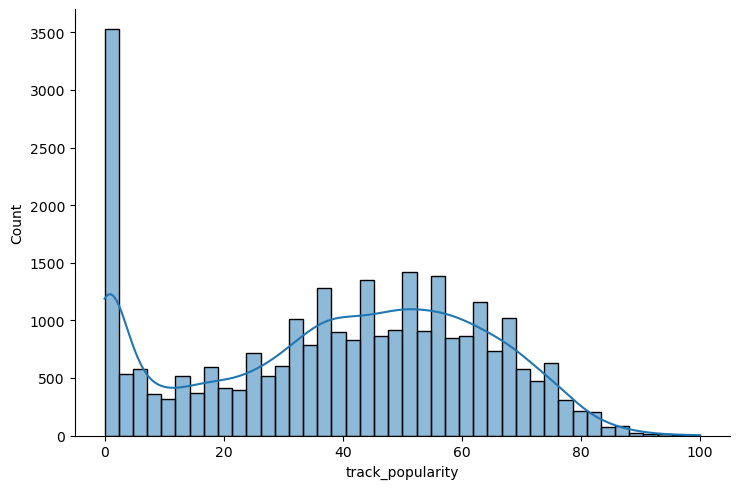

In [38]:
sns.displot(data = df01, x='track_popularity', kind='hist', kde=True, aspect=1.5)

plt.show()

Most of the data points are clustered near 0. This is an important factor to account for during model fitting and training, as it can influence how the model learns patterns in the data.

## Categotical-to-categorical relationships 

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


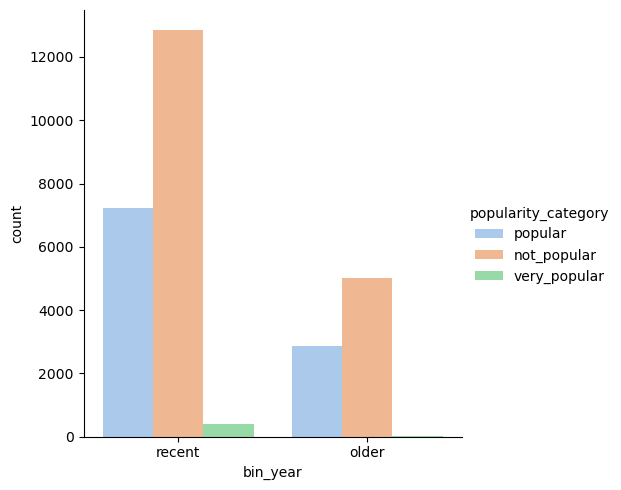

In [39]:
sns.catplot(data = df01, x='bin_year', hue='popularity_category', kind='count', palette='pastel')

plt.show()

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


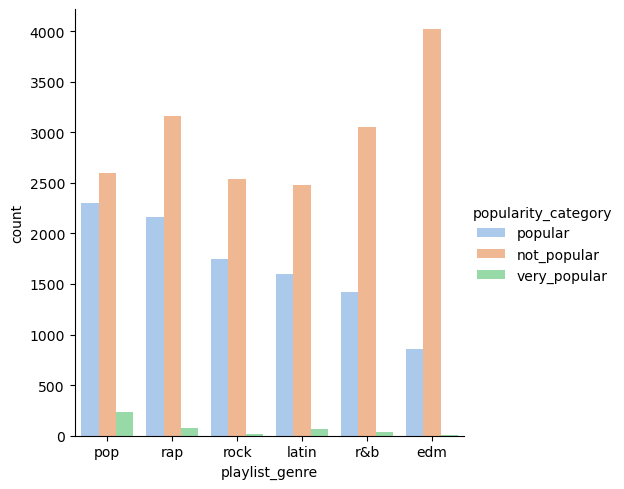

In [40]:
sns.catplot(data = df01, x='playlist_genre', hue='popularity_category', kind='count', palette='pastel')

plt.show()

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


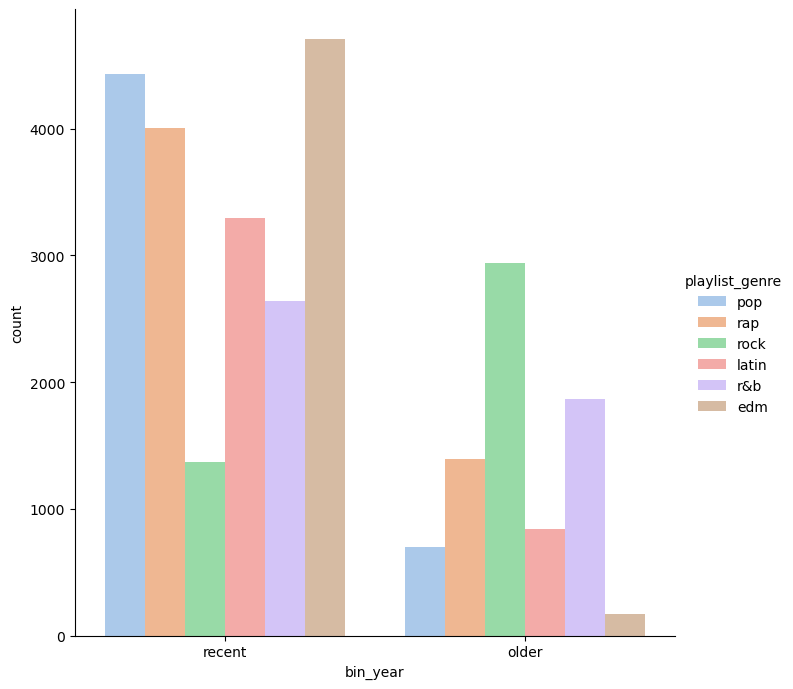

In [41]:
sns.catplot(data = df01, x='bin_year', hue='playlist_genre', kind='count', height=7, palette='pastel')

plt.show()

#### Discussion of categorical-to-categorical relationships
Since most values are close to 0, the dominant condition is 'not_popular', which is evident when grouping by the `popularity_category`. Similarly, when grouping by `bin_year`, the dominant condition is 'recent', as most values fall in the year 2019.

## Summaries of the continuous variables grouped by categorical variables

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


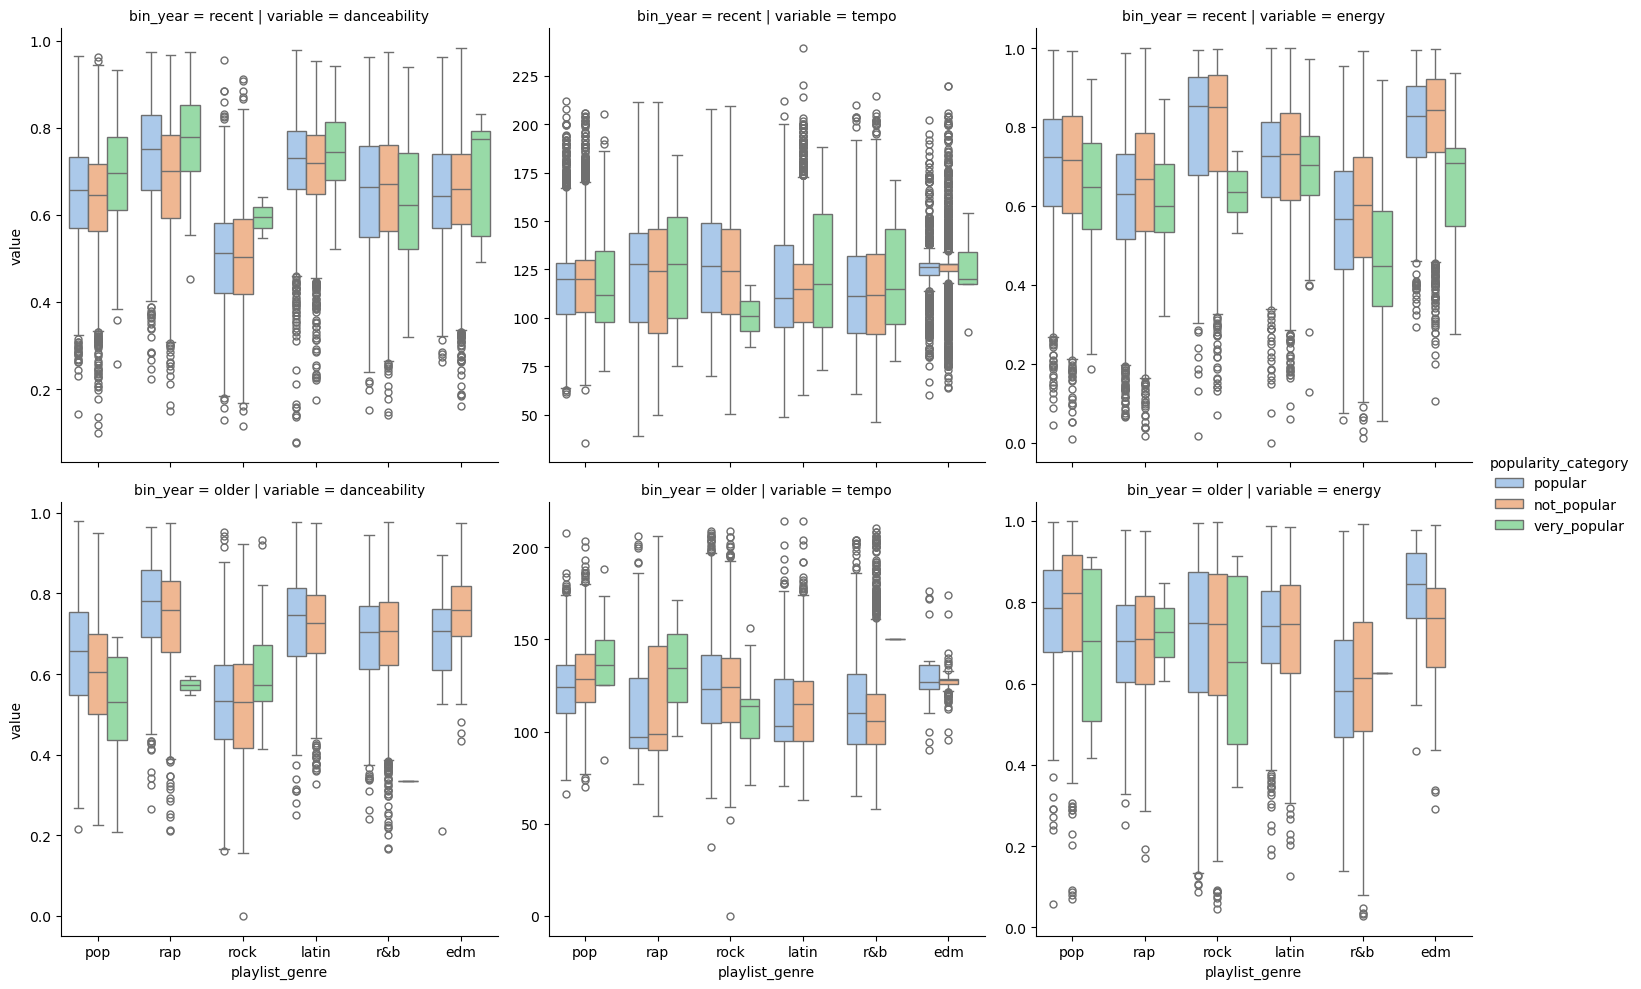

In [60]:
sns.catplot( data = df_lf, y='value', col='variable', x='playlist_genre', hue='popularity_category', kind='box',
            row='bin_year', sharey=False, palette='pastel')

plt.show()

The boxplot visualization shows the distribution of `danceability`, `tempo`, and `energy` across different `playlist_genres`, grouped by `popularity_category` and `bin_year`.

In the older songs, we notice that the 'very_popular' category is absent for Latin, R&B, and EDM genres. This suggests that highly popular tracks in these genres are more recent, possibly reflecting shifting trends in listener preferences.

Across several variables, the median values and distribution shapes (box widths and whiskers) for the 'very_popular' songs differ from those of the 'not_popular' and 'popular' categories.

These differences highlight how certain audio features may be linked to a song's popularity, and how this relationship can vary by genre and time period.

## Continous-to-continous relationship

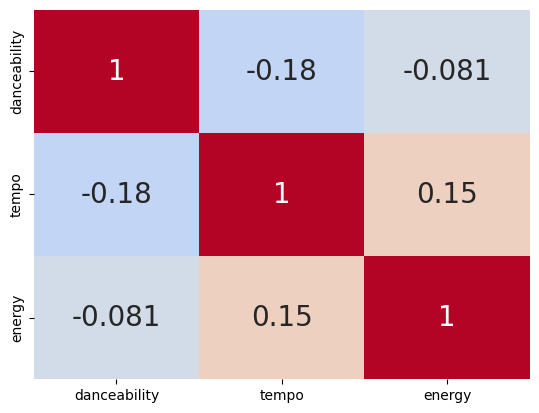

In [46]:
fig, ax = plt.subplots()

sns.heatmap(data = df01.loc[:, ['danceability', 'tempo', 'energy']].corr(),
            vmin=-1, vmax=1, center=0,
            cmap='coolwarm', cbar=False,
            annot=True, annot_kws={'size':20}, 
            ax=ax)

plt.show()

These low correlations suggest that the features are not strongly linearly related to one another.This low level of correlation is useful when training models, as it reduces the risk of multicollinearity, allowing each feature to contribute more independently to the model's learning process.

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


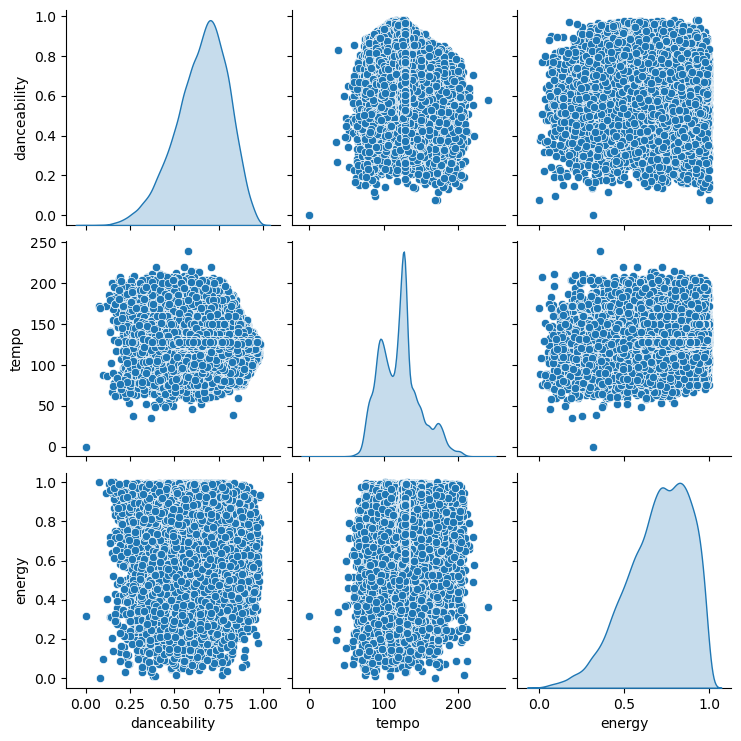

In [47]:
sns.pairplot( data = df_features, diag_kind='kde',  diag_kws={'common_norm': False})

plt.show()

## Categorical inputs group by `populatory_category`.

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


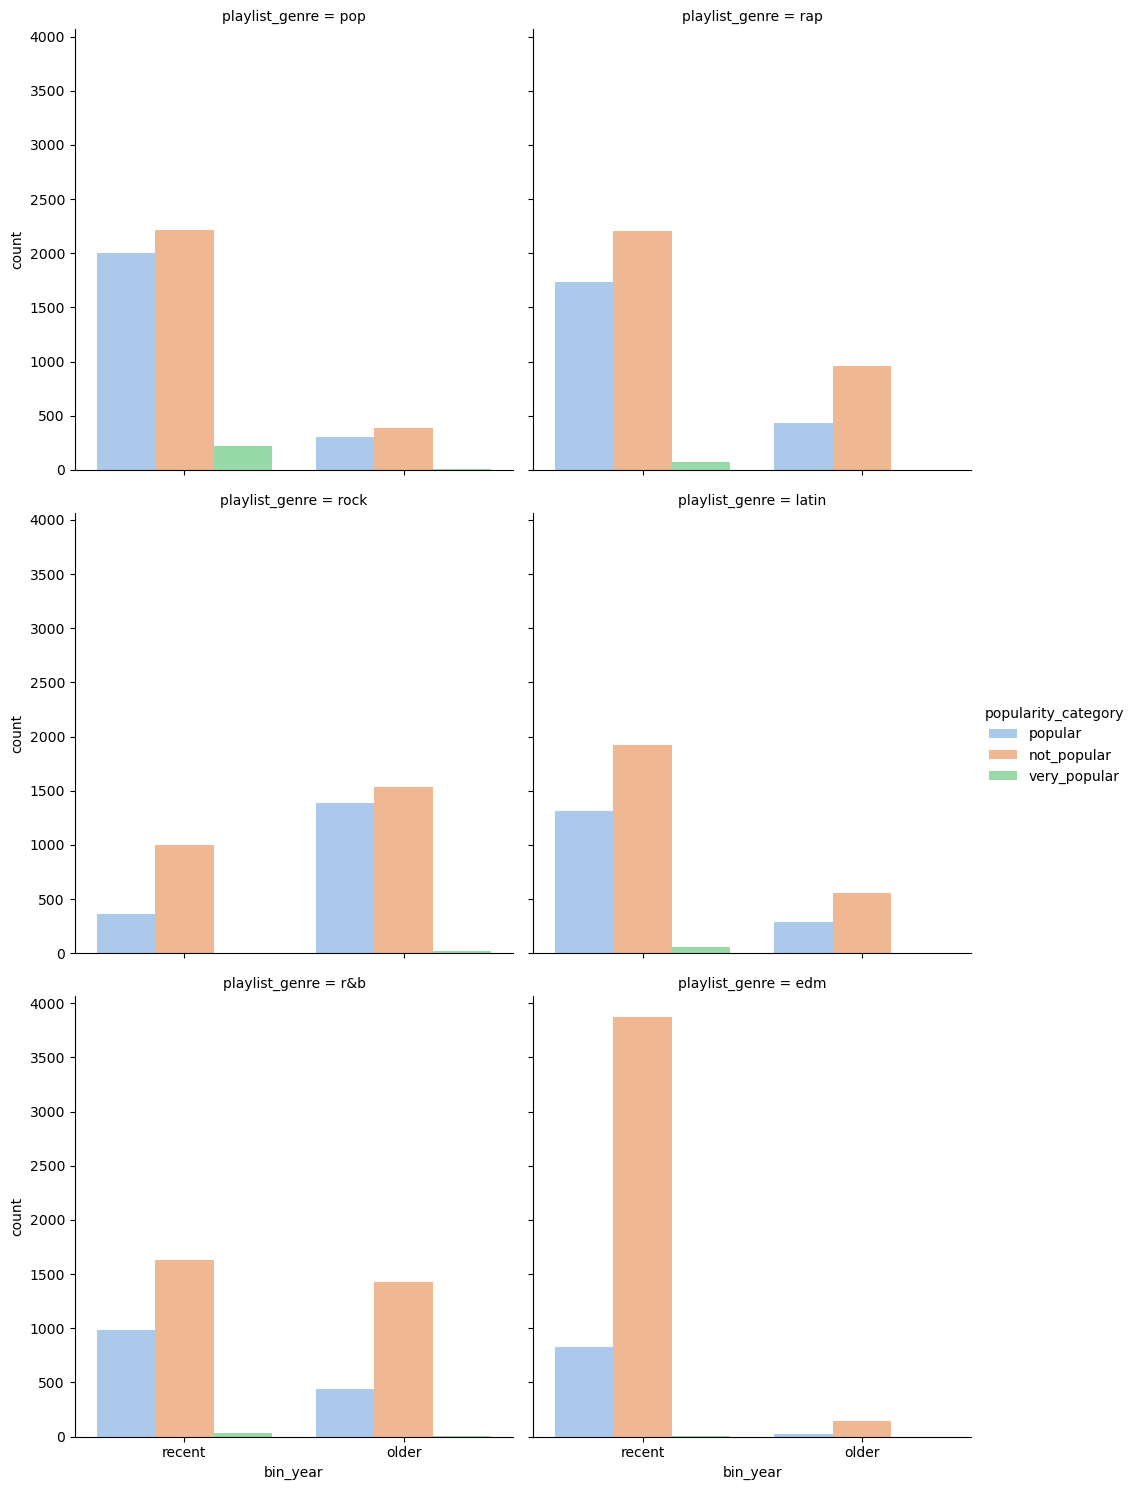

In [48]:
sns.catplot(data = df01, x='bin_year', hue='popularity_category', col='playlist_genre', col_wrap=2, kind='count', palette='pastel')

plt.show()

The number of 'very_popular' songs is noticeably low, especially in the older bin, where some genres have very few or no entries in this category. These patterns suggest that highly popular songs are relatively rare in the dataset, regardless of genre or time period, and that the dataset is skewed toward less popular tracks.

## Conditional distributions of the continuos inputs group by `populatory_category`.

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


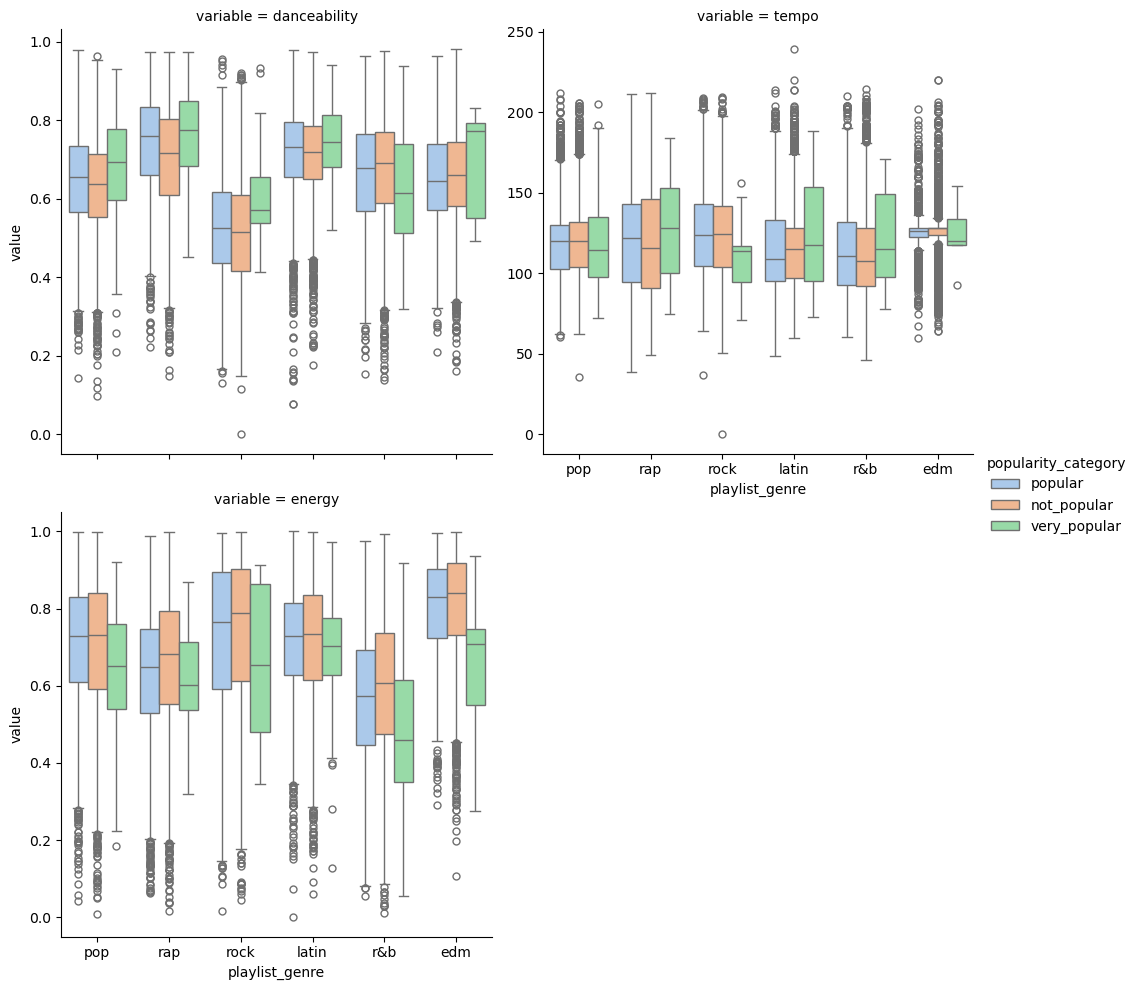

In [49]:
sns.catplot(data = df_lf, x='playlist_genre', y='value', col='variable', hue='popularity_category', kind='box', col_wrap=2,
            sharey=False, palette='pastel')

plt.show()

## Relationships between continuous inputs group by `populatory_category`.

In [50]:
the_pgroup = df01.popularity_category.unique().tolist()
the_pgroup

['popular', 'not_popular', 'very_popular']

In [51]:
corr_group = df01.loc[ :, ['danceability', 'tempo', 'energy', 'popularity_category']].groupby(['popularity_category']).\
corr()

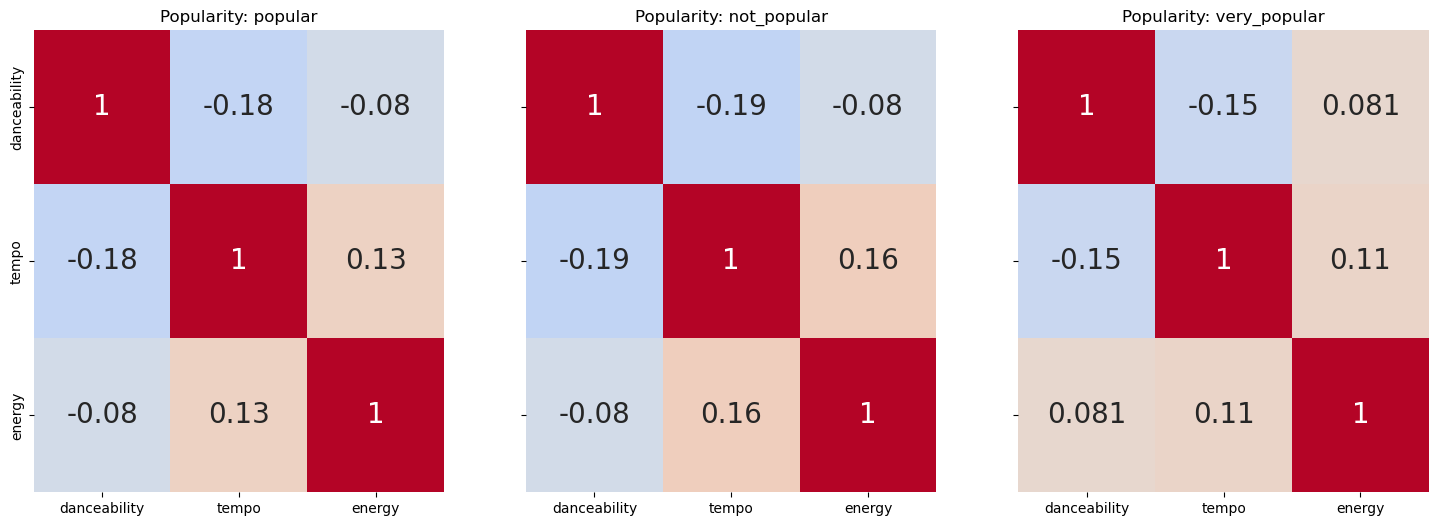

In [52]:
fig, axs = plt.subplots(1, len(the_pgroup), figsize=(18,6), sharex=True, sharey=True)

for ix in range(len(the_pgroup)):
    sns.heatmap( data = corr_group.loc[ the_pgroup[ ix ] ],
                vmin=-1, vmax=1, center = 0, 
                cmap='coolwarm', cbar=False,
                annot=True, annot_kws={'size': 20},
                ax=axs[ix])
    axs[ix].set_title('Popularity: %s' % the_pgroup[ix])

plt.show()

Low correlations grouped by `popularity_category` mean features are mostly independent of each other within each group, and popularity doesn't strongly change how they interact.

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


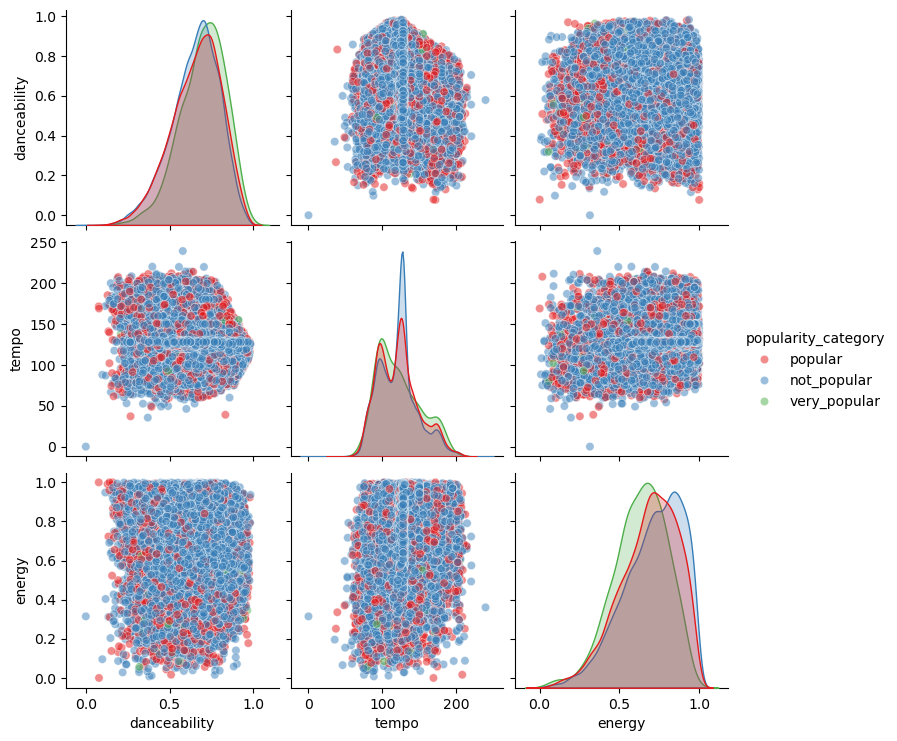

In [53]:
sns.pairplot(data = df01.loc[ :, ['danceability', 'tempo', 'energy', 'popularity_category']],
             hue='popularity_category', diag_kind='kde',  diag_kws={'common_norm': False}, 
             plot_kws={'alpha': 0.5}, palette='Set1')

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


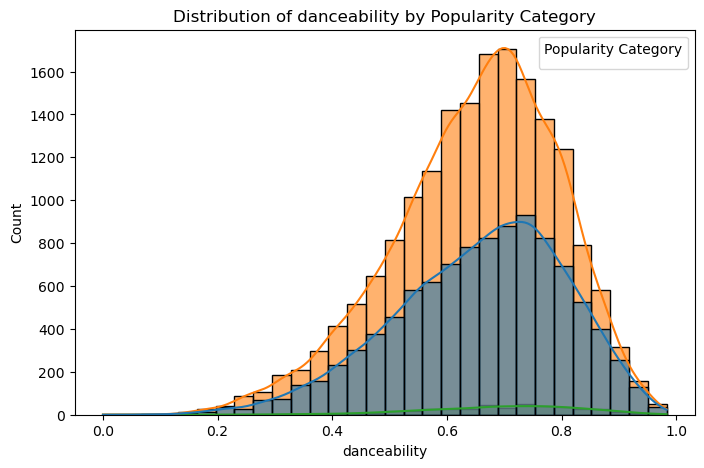

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


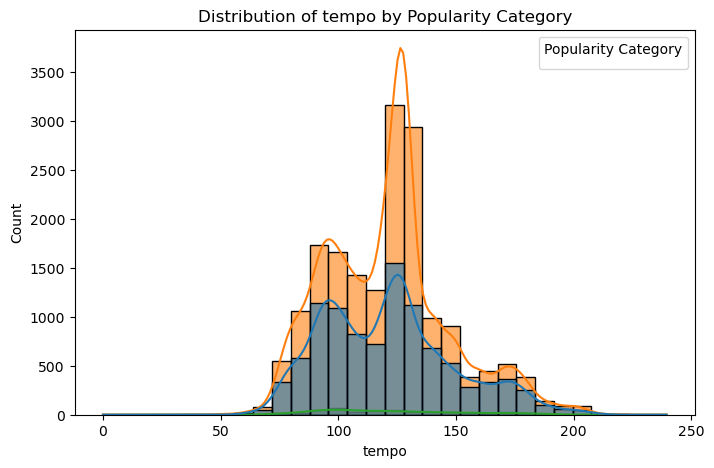

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


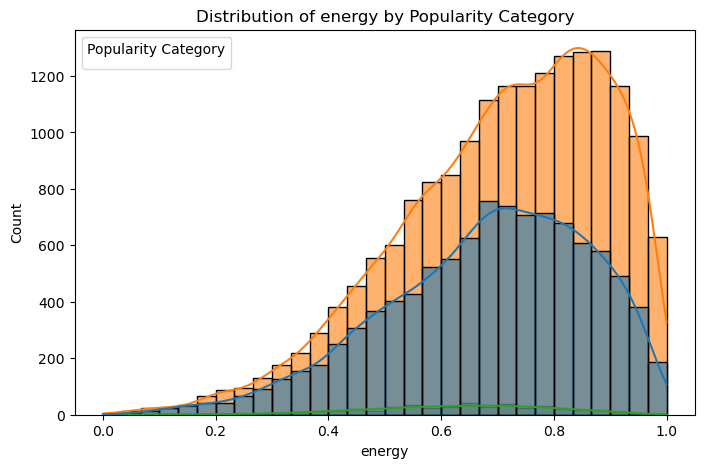

In [54]:
for var in df_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df01, x=var, hue='popularity_category', kde=True, bins=30, alpha=0.6)
    plt.title(f'Distribution of {var} by Popularity Category')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.legend(title='Popularity Category')
    plt.show()

<Figure size 1200x600 with 0 Axes>

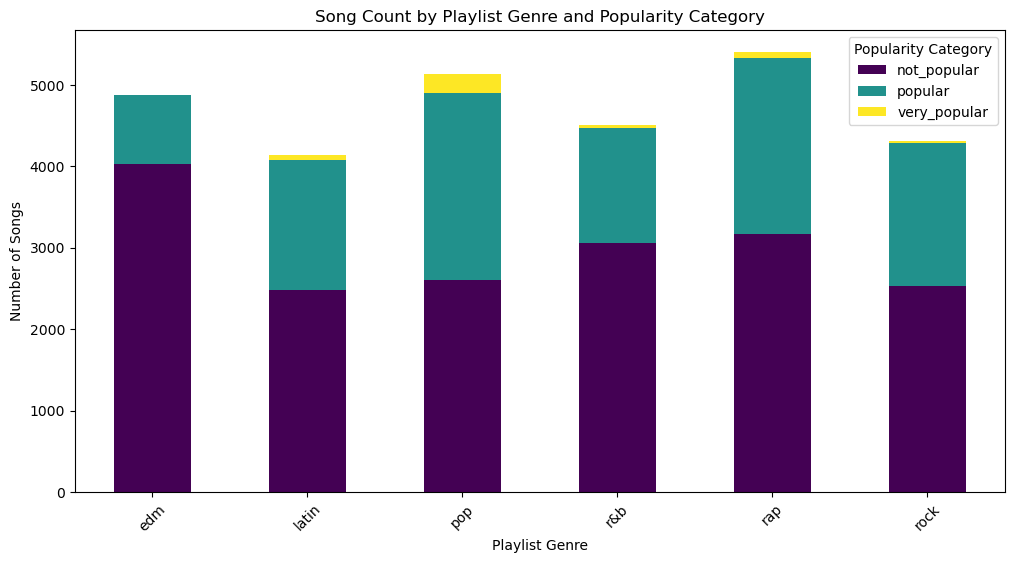

In [55]:
plt.figure(figsize=(12, 6))
genre_plot = df01.groupby(['playlist_genre', 'popularity_category']).size().unstack()

genre_plot.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Song Count by Playlist Genre and Popularity Category")
plt.xlabel("Playlist Genre")
plt.ylabel("Number of Songs")
plt.legend(title="Popularity Category")
plt.xticks(rotation=45)
plt.show()

Across all genres, the majority of songs fall into the "not_popular" category, with the least representation in the "very_popular" category.

Genres like rap and edm have a relatively higher number of very popular songs compared to genres like r&b or latin.

Despite the volume of songs being high in some genres like pop and rap, the distribution heavily leans towards the less popular category, reinforcing the imbalance in popularity labels across genres.

<Figure size 1000x500 with 0 Axes>

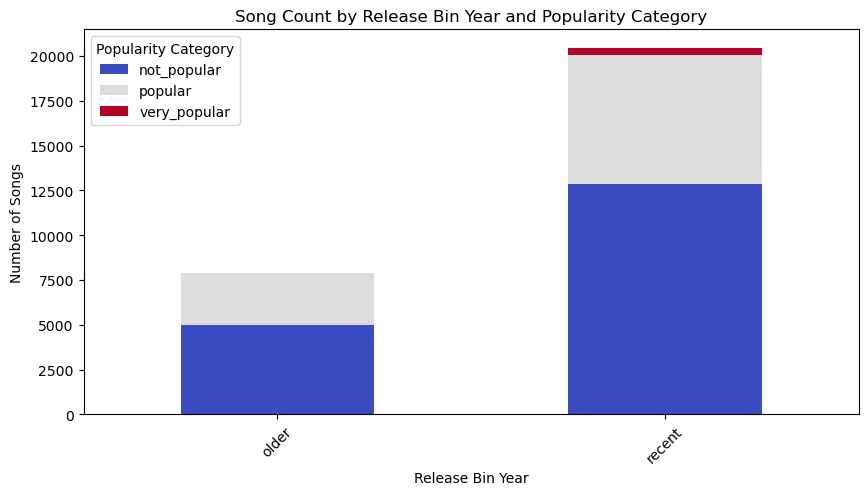

In [56]:
# Plot the count of songs per bin year and popularity category
plt.figure(figsize=(10, 5))
bin_year_plot = df01.groupby(['bin_year', 'popularity_category']).size().unstack()

bin_year_plot.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='coolwarm')
plt.title("Song Count by Release Bin Year and Popularity Category")
plt.xlabel("Release Bin Year")
plt.ylabel("Number of Songs")
plt.legend(title="Popularity Category")
plt.xticks(rotation=45)
plt.show()


There is a much higher number of recent songs, showing either a bias in data collection toward newer music or a trend of increased music production over time.

Interestingly, while both bins are still dominated by "not_popular" songs, recent songs show a notable increase in the "popular" and "very_popular" categories compared to older songs.

This could suggest that newer songs have better visibility or engagement, or that popularity is more skewed toward recent releases.

In [57]:
df01.to_csv('df_EDA', index=False)